# Clasificación de Supervivencia en el Titanic — Regresión Logística, KNN, Naive Bayes y Random Forest

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Automático Estadístico — MIA-B
**Docente:** PhD. Iván García Santillán
**Semana 1 — Componente práctico (Práctica Grupal — Grupo 2)**

**Integrantes (Grupo 2):**
- Gualli Ramírez, Jonathan Fabricio
- Quizamánchuro Fuel, Jorge Armando
- Salazar Gamboa, Raúl Marcelo

---

## Resumen del trabajo

Este notebook desarrolla un flujo completo de **clasificación binaria supervisada** sobre el dataset
**Titanic**, con el objetivo de predecir la **supervivencia** de un pasajero (`Survived`) a partir de
sus características socio-demográficas y de viaje. Se aplica exactamente la misma metodología y los
mismos tres algoritmos que en la práctica de cáncer de mama, lo que permite **comparar** el
comportamiento de los modelos en un dataset *pequeño y "sucio"* (mucho preprocesamiento) frente a uno
*curado*.

El trabajo se organiza en tres fases:

1. **Fase I — Preprocesamiento:** carga, entendimiento del negocio (la película), verificación de
   valores perdidos, imputación de `Age` (mediana) y `Embarked` (moda), codificación de variables
   categóricas (`Sex`, `Embarked`), eliminación de columnas no informativas
   (`PassengerId`, `Name`, `Ticket`, `Cabin`), *feature engineering* (`FamilySize`, `IsAlone`),
   análisis de atípicos por IQR y normalización con `StandardScaler` y `MinMaxScaler`.
2. **Fase II — Análisis Exploratorio (EDA):** balance de clases, estadística descriptiva, histogramas,
   boxplots, supervivencia por sexo y clase, matriz de correlación y selección de características por
   correlación con el objetivo.
3. **Fase III — Modelado y Evaluación:** **Regresión Logística**, **KNN** y **Naive Bayes**, cada uno
   en versión *baseline* (por defecto) y *mejorada* (`GridSearchCV` + selección de características),
   con matrices de confusión, curvas ROC/AUC y una tabla comparativa final.

**Nota de contraste con el notebook de cáncer de mama.** Allí la clase positiva era el tumor
*maligno* y la métrica prioritaria el **Recall** (un Falso Negativo es letal). Aquí la clase
positiva es *sobrevivió*, y los dos tipos de error tienen un costo simétrico (es un problema
histórico-analítico, no clínico). Por eso aquí **optimizamos F1** (equilibrio precision/recall) y
reportamos todas las métricas. Esto ilustra el principio del docente: *la métrica a priorizar
depende del contexto del problema*.

## 1. Configuración del entorno y carga de librerías

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

warnings.filterwarnings("ignore")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Rutas relativas desde semana-1/notebook (mismo esquema que el notebook de cáncer)
NB_DIR = Path.cwd()
PROJ_DIR = NB_DIR.parent           # semana-1/
MODELS_DIR = PROJ_DIR / "models"
OUT_DIR = PROJ_DIR / "outputs"
DATA_DIR = PROJ_DIR / "data"
MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("scikit-learn, pandas y seaborn cargados correctamente.")
print(f"Modelos se guardarán en: {MODELS_DIR}")

scikit-learn, pandas y seaborn cargados correctamente.
Modelos se guardarán en: /Users/jorgequizamanchuro/Documents/Proyectos/UIDE/UIDE-Aprendizaje-Automatico-Estadistico/semana-1/models


---
# Fase I — Preprocesamiento

A diferencia del dataset de cáncer de mama (ya curado por especialistas), el Titanic es un dataset
pequeño pero **"sucio"**: tiene valores perdidos, variables categóricas en texto y columnas sin valor
predictivo.

## 2. Carga del dataset y variable objetivo

**Entendimiento del negocio (la película).** La variable objetivo `Survived` indica si el pasajero
sobrevivió (`1`) o no (`0`). Sabemos por el contexto histórico que tuvieron prioridad **mujeres y
niños** y los pasajeros de **primera clase** (ubicados en cubiertas superiores), lo que anticipa que
`Sex`, `Pclass` y `Age` serán variables muy informativas.

In [2]:
CSV_PATH = DATA_DIR / "titanic_train.csv"
if not CSV_PATH.exists():               # respaldo por si el nombre cambia
    CSV_PATH = DATA_DIR / "titanic.csv"
df = pd.read_csv(CSV_PATH)

# Codificación objetivo: 1 = Sobrevivió (positivo), 0 = No sobrevivió (negativo)
LABELS = {1: "Sobrevivió", 0: "No sobrevivió"}

print(f"Archivo cargado: {CSV_PATH.name}")
print(f"Dimensiones: {df.shape[0]} pasajeros x {df.shape[1]} columnas")
print("\nDistribución de la clase objetivo:")
print(df["Survived"].map(LABELS).value_counts())
df.head()

Archivo cargado: titanic_train.csv
Dimensiones: 891 pasajeros x 12 columnas

Distribución de la clase objetivo:
Survived
No sobrevivió    549
Sobrevivió       342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Entendimiento de los datos: tipos y descripción de variables

Revisamos el tipo de dato de cada columna. Esto nos dice qué variables son categóricas (texto) y
deberán codificarse, y cuáles son numéricas. Descripción de las 12 columnas originales:

| Variable | Significado | Decisión preliminar |
|---|---|---|
| `PassengerId` | Identificador único | **Eliminar** (no aporta) |
| `Survived` | Sobrevivió (1) / no (0) | **Objetivo (target)** |
| `Pclass` | Clase del billete (1ª/2ª/3ª) ~ nivel socioeconómico | Conservar |
| `Name` | Nombre completo | **Eliminar** (valor único) |
| `Sex` | Sexo | Conservar — **codificar** |
| `Age` | Edad en años | Conservar — **imputar nulos** |
| `SibSp` | N.º de hermanos/cónyuge a bordo | Conservar |
| `Parch` | N.º de padres/hijos a bordo | Conservar |
| `Ticket` | N.º de billete | **Eliminar** (alfanumérico no informativo) |
| `Fare` | Tarifa pagada | Conservar |
| `Cabin` | Cabina | **Eliminar** (~77% nulos) |
| `Embarked` | Puerto de embarque (S/C/Q) | Conservar — **codificar + imputar** |

In [3]:
print("Tipos de datos:")
print(df.dtypes)
print("\nEstadística descriptiva (variables numéricas):")
df.describe().T.round(2)

Tipos de datos:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Estadística descriptiva (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.00,257.35,1.00,223.50,446.00,668.5,891.00
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


## 4. Verificación de valores perdidos

Reportamos los nulos por columna. En el Titanic son significativos, a diferencia del WBCD.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_table = pd.DataFrame({"n_nulos": missing, "porcentaje": missing_pct})
print(miss_table[miss_table.n_nulos > 0].to_string())
print(f"\nTotal de celdas perdidas: {int(missing.sum())}")

          n_nulos  porcentaje
Age           177        19.9
Cabin         687        77.1
Embarked        2         0.2

Total de celdas perdidas: 866


## 5. Preprocesamiento: limpieza, imputación, codificación y *feature engineering*

Aplicamos las decisiones tomadas, con su justificación:

1. **Eliminar** `PassengerId`, `Name`, `Ticket` (no informativas) y `Cabin` (~77% nulos → imputar
   sería inventar datos).
2. **Imputar `Age`** con la **mediana** (≈28). Se prefiere la mediana a la media porque la variable
   tiene atípicos (bebés y adultos mayores) que sesgarían la media.
3. **Imputar `Embarked`** con la **moda** (`S`), por ser una variable **categórica** (solo 2 nulos).
4. **Codificar** `Sex` (female=0, male=1) y `Embarked` (S=0, C=1, Q=2) a numérico, requisito de casi
   todos los algoritmos.
5. ***Feature engineering*:** crear `FamilySize = SibSp + Parch + 1` (tamaño del grupo familiar a
   bordo) e `IsAlone` (1 si viaja solo). Combinar `SibSp` y `Parch` reduce multicolinealidad
   (en clase se vio que correlacionan ≈0.41).

In [5]:
df_clean = df.copy()

# 1) Eliminar columnas no informativas
df_clean = df_clean.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# 2) Imputar Age con la mediana
age_median = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].fillna(age_median)

# 3) Imputar Embarked con la moda
embarked_mode = df_clean["Embarked"].mode()[0]
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)

# 4) Codificar categóricas
df_clean["Sex"] = df_clean["Sex"].map({"female": 0, "male": 1})
df_clean["Embarked"] = df_clean["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# 5) Feature engineering
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

print(f"Mediana de Age usada para imputar: {age_median}")
print(f"Moda de Embarked usada para imputar: '{embarked_mode}'")
print(f"\nValores perdidos tras el preprocesamiento: {int(df_clean.isnull().sum().sum())}")
print(f"Dimensiones finales: {df_clean.shape}")
df_clean.head()

Mediana de Age usada para imputar: 28.0
Moda de Embarked usada para imputar: 'S'

Valores perdidos tras el preprocesamiento: 0
Dimensiones finales: (891, 10)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,0,2,0
1,1,1,0,38.0,1,0,71.2833,1,2,0
2,1,3,0,26.0,0,0,7.9250,0,1,1
3,1,1,0,35.0,1,0,53.1000,0,2,0
4,0,3,1,35.0,0,0,8.0500,0,1,1


## 6. Detección y tratamiento de valores atípicos (método IQR)

Detectamos atípicos con el rango intercuartílico: un valor es atípico si cae fuera de
$[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$. Igual que en el notebook de cáncer,
**cuantificamos** los atípicos pero la decisión de eliminarlos se toma **empíricamente** en la
Fase III (experimento "eliminar vs conservar"). En el Titanic los atípicos de `Fare` (billetes muy
caros de 1ª clase) y `Age` son **reales**, no errores de medición.

In [6]:
feature_cols = [c for c in df_clean.columns if c != "Survived"]
numeric_for_iqr = ["Age", "SibSp", "Parch", "Fare", "FamilySize"]

def iqr_outlier_mask(frame, cols):
    # Devuelve (mascara booleana True=fila con >=1 atipico IQR, dict de conteos por columna)
    mask = pd.Series(False, index=frame.index)
    counts = {}
    for col in cols:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (frame[col] < low) | (frame[col] > high)
        counts[col] = int(col_out.sum())
        mask |= col_out
    return mask, counts

outlier_mask, outlier_counts = iqr_outlier_mask(df_clean, numeric_for_iqr)
n_rows_outlier = int(outlier_mask.sum())
print(f"Filas con al menos un atípico IQR: {n_rows_outlier} de {len(df_clean)} "
      f"({100*n_rows_outlier/len(df_clean):.1f}%)")
print("\nAtípicos por variable:")
print(pd.Series(outlier_counts).sort_values(ascending=False))

Filas con al menos un atípico IQR: 314 de 891 (35.2%)

Atípicos por variable:
Parch         213
Fare          116
FamilySize     91
Age            66
SibSp          46
dtype: int64


---
# Fase II — Análisis Exploratorio de Datos (EDA)

Entender la estructura de los datos antes de modelar nos permite detectar el desbalance de clases,
identificar las variables más informativas y justificar la selección de características con criterio
estadístico.

## 7. Distribución de la variable objetivo (balance de clases)

En clase se vio que **549 pasajeros no sobrevivieron y 342 sí** (≈62% / 38%). Es un desbalance
**moderado**, no severo, por lo que no requiere remuestreo, pero sí conviene mirar recall/F1 además
del accuracy.

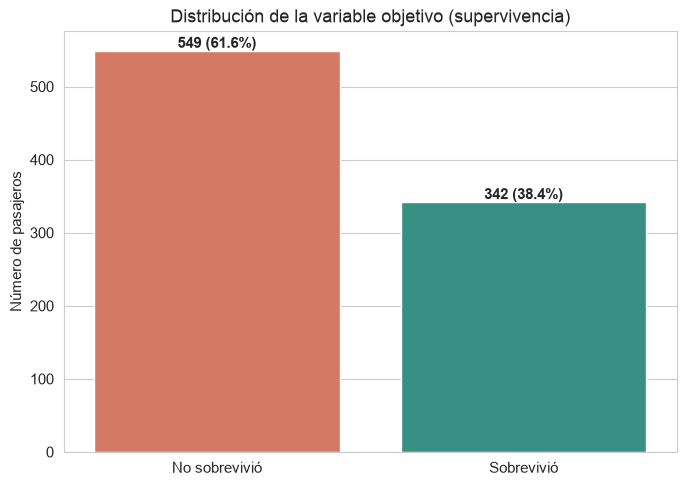

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df_clean["Survived"].map(LABELS).value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=["#e76f51", "#2a9d8f"], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f"{v} ({100*v/len(df_clean):.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo (supervivencia)")
ax.set_ylabel("Número de pasajeros"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "t01_distribucion_clases.png", dpi=120); plt.show()

## 8. Supervivencia por sexo y por clase (entendimiento del negocio)

Validamos estadísticamente la intuición de la película: ¿sobrevivieron más las mujeres y la primera
clase?

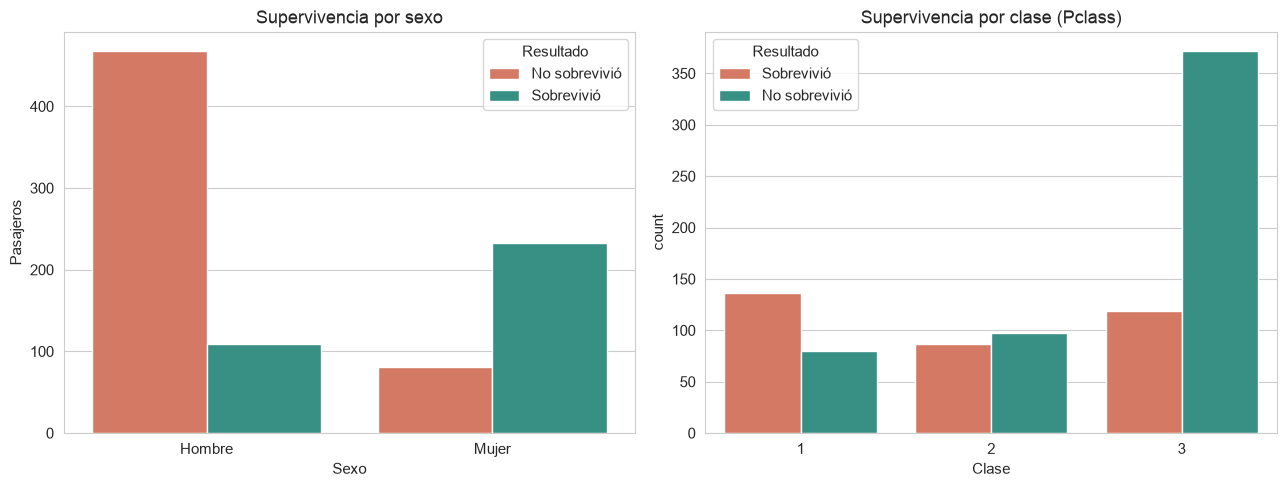

Tasa de supervivencia por sexo:
Sex
Mujer     0.742
Hombre    0.189
Name: Survived, dtype: float64

Tasa de supervivencia por clase:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sex_labels = {0: "Mujer", 1: "Hombre"}
tmp = df_clean.assign(Sexo=df_clean["Sex"].map(sex_labels),
                      Resultado=df_clean["Survived"].map(LABELS))
sns.countplot(data=tmp, x="Sexo", hue="Resultado",
              palette=["#e76f51", "#2a9d8f"], ax=axes[0])
axes[0].set_title("Supervivencia por sexo"); axes[0].set_ylabel("Pasajeros")

sns.countplot(data=tmp, x="Pclass", hue="Resultado",
              palette=["#e76f51", "#2a9d8f"], ax=axes[1])
axes[1].set_title("Supervivencia por clase (Pclass)"); axes[1].set_xlabel("Clase")
plt.tight_layout(); plt.savefig(OUT_DIR / "t02_superv_sexo_clase.png", dpi=120); plt.show()

print("Tasa de supervivencia por sexo:")
print(df_clean.groupby("Sex")["Survived"].mean().rename(index=sex_labels).round(3))
print("\nTasa de supervivencia por clase:")
print(df_clean.groupby("Pclass")["Survived"].mean().round(3))

## 9. Correlación de cada variable con el objetivo y selección de características

Calculamos la correlación de Pearson de cada predictora con `Survived`. **Nota importante:** en el
Titanic las correlaciones son **más débiles** que en el WBCD (donde varias superaban 0.7). Aquí la
más fuerte es `Sex`. Por eso usamos un umbral **|r| > 0.1** (en lugar del 0.4 del cáncer) para la
selección de características de la versión mejorada.

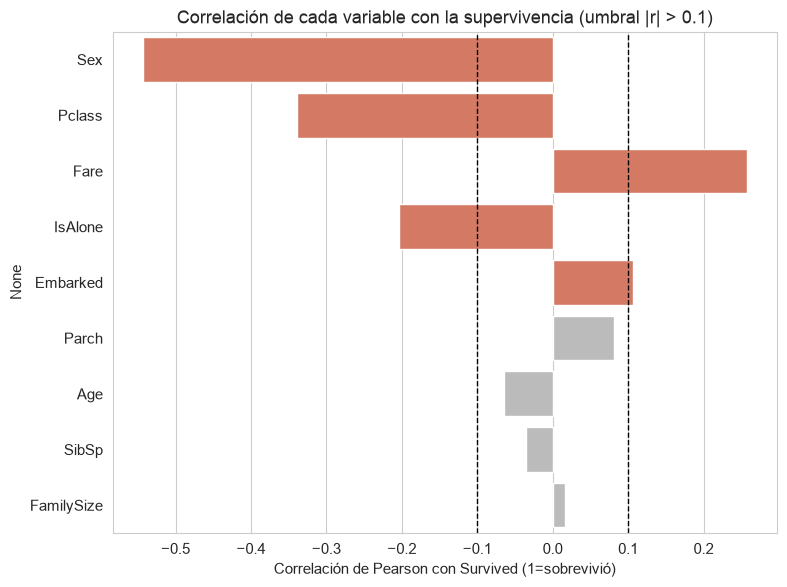

Variables seleccionadas (|r| > 0.1): 5 de 9
  Sex            r = -0.543
  Pclass         r = -0.338
  Fare           r = +0.257
  IsAlone        r = -0.203
  Embarked       r = +0.107


In [9]:
corr_target = df_clean.corr(numeric_only=True)["Survived"].drop("Survived").sort_values(key=np.abs, ascending=False)

THRESHOLD = 0.1
selected_features = corr_target[corr_target.abs() > THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e76f51" if abs(v) > THRESHOLD else "#bbbbbb" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors, ax=ax)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1); ax.axvline(-THRESHOLD, color="k", ls="--", lw=1)
ax.set_title(f"Correlación de cada variable con la supervivencia (umbral |r| > {THRESHOLD})")
ax.set_xlabel("Correlación de Pearson con Survived (1=sobrevivió)")
plt.tight_layout(); plt.savefig(OUT_DIR / "t03_correlacion_target.png", dpi=120); plt.show()

print(f"Variables seleccionadas (|r| > {THRESHOLD}): {len(selected_features)} de {len(feature_cols)}")
for f in selected_features:
    print(f"  {f:<14} r = {corr_target[f]:+.3f}")

## 10. Histogramas de las variables más predictivas

Comparamos la distribución de las variables más correlacionadas, separadas por clase.

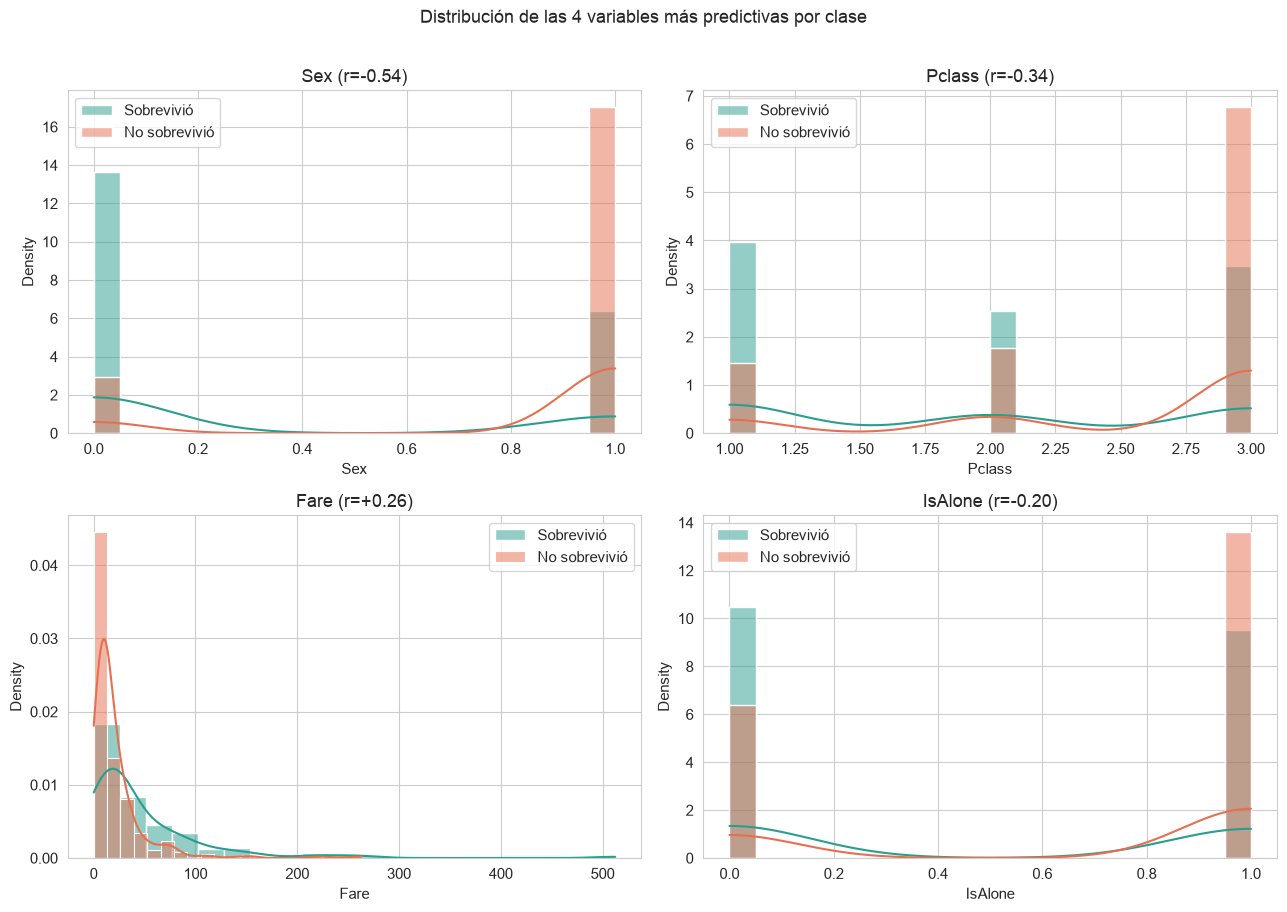

In [10]:
top4 = selected_features[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    for cls, color in [(1, "#2a9d8f"), (0, "#e76f51")]:
        sns.histplot(df_clean[df_clean.Survived == cls][col], ax=ax, color=color,
                     label=LABELS[cls], kde=True, stat="density", alpha=0.5, bins=20)
    ax.set_title(f"{col} (r={corr_target[col]:+.2f})"); ax.legend()
fig.suptitle("Distribución de las 4 variables más predictivas por clase", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "t04_histogramas_top.png", dpi=120); plt.show()

## 11. Boxplots de variables continuas (detección visual de atípicos)

Los boxplots de `Age` y `Fare` confirman el análisis IQR de la Fase I: existen valores extremos,
sobre todo en `Fare` (billetes de lujo de 1ª clase).

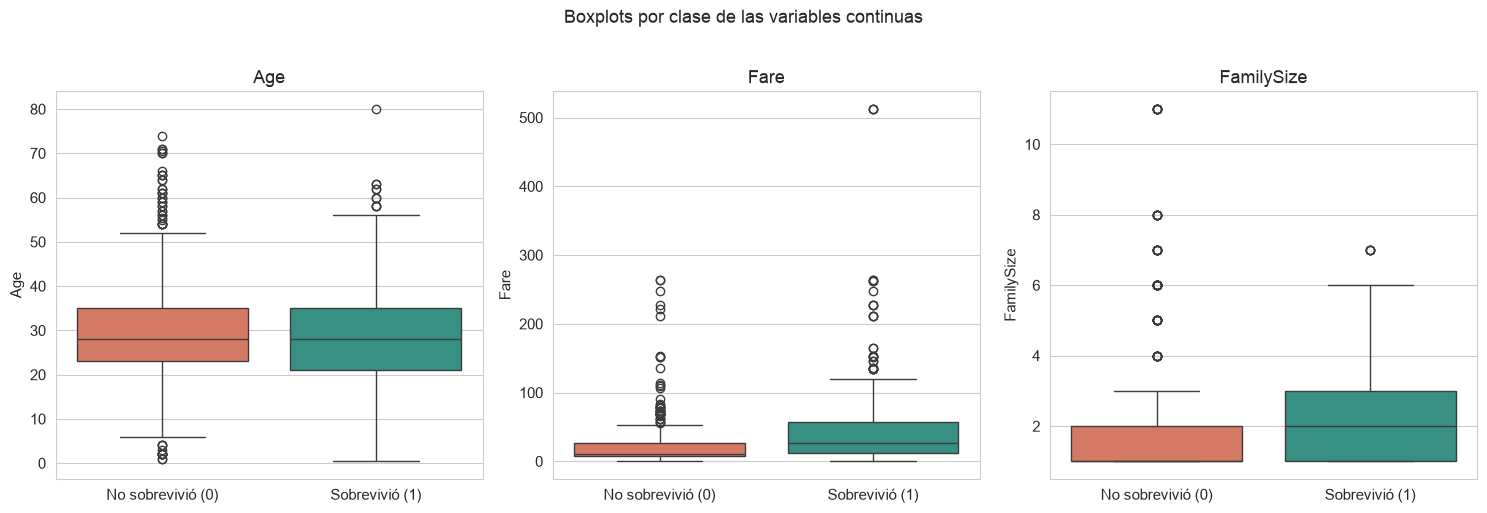

In [11]:
cont_vars = ["Age", "Fare", "FamilySize"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cont_vars):
    sns.boxplot(data=df_clean, x="Survived", y=col,
                palette=["#e76f51", "#2a9d8f"], ax=ax)
    ax.set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"])
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Boxplots por clase de las variables continuas", y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "t05_boxplots.png", dpi=120); plt.show()

## 12. Matriz de correlación entre predictoras

Buscamos **multicolinealidad**. Esperamos correlación alta entre `Pclass` y `Fare` (en clase salió
≈-0.54) y entre `SibSp`/`Parch` y `FamilySize` (por construcción).

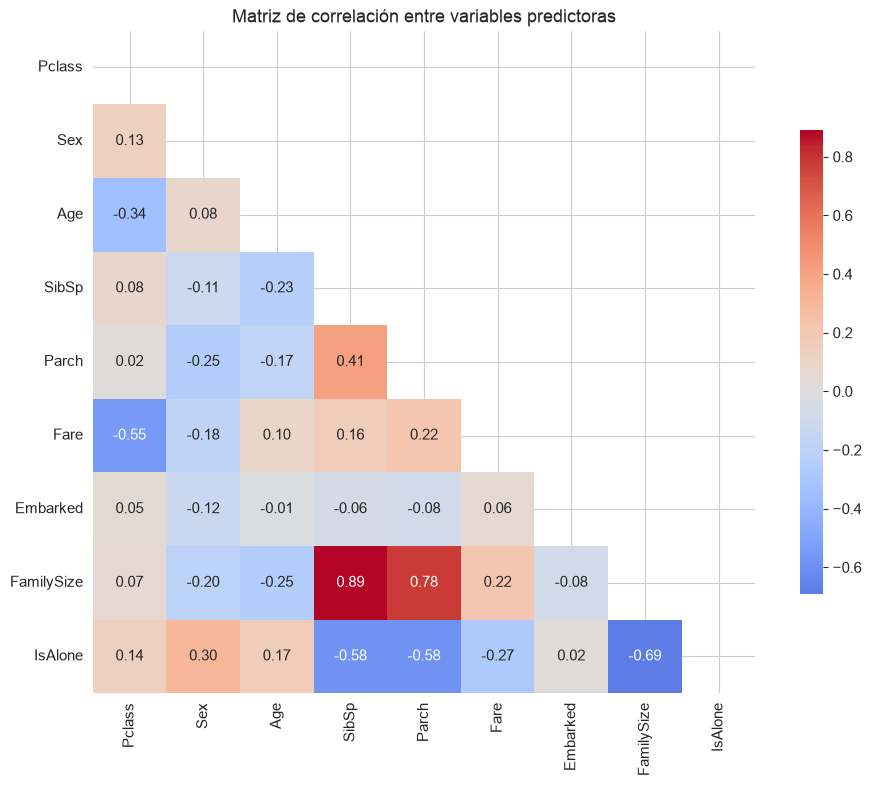

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, square=True,
            annot=True, fmt=".2f", cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación entre variables predictoras")
plt.tight_layout(); plt.savefig(OUT_DIR / "t06_heatmap_correlacion.png", dpi=120); plt.show()

### Interpretación del EDA

- **Balance:** desbalance moderado (≈62% no sobrevivió / 38% sobrevivió). No exige remuestreo.
- **Variables más predictivas:** `Sex` (la más fuerte con diferencia), `Pclass` y `Fare` —coherente
  con la intuición histórica: mujeres y pasajeros de clase alta sobrevivieron más.
- **Multicolinealidad:** `Pclass`–`Fare` (negativa, a mayor clase menor precio) y
  `SibSp`/`Parch`–`FamilySize` (por construcción). Justifica haber combinado en `FamilySize`.
- **Señal más débil que en el WBCD:** ninguna correlación supera 0.55, frente a |r|>0.7 en cáncer.
  Esto anticipa **métricas más bajas** (≈80-85%) que en el dataset clínico (≈97%): un dataset más
  difícil produce modelos menos precisos.

---
# Fase III — Modelado y Evaluación

Entrenamos cuatro clasificadores, cada uno en dos versiones (*baseline* y *mejorada*).
Mantenemos un **conjunto de prueba intacto (20%)** con división **estratificada** y `random_state=42`
en todo el flujo.

## 13. División train/test y preparación de escaladores

In [13]:
X = df_clean[feature_cols].copy()
y = df_clean["Survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape[0]} pasajeros | Test: {X_test.shape[0]} pasajeros")
print(f"Balance train: {dict(y_train.map(LABELS).value_counts())}")
print(f"Balance test : {dict(y_test.map(LABELS).value_counts())}")

# Escaladores ajustados SOLO con train (evita fuga de información)
std_scaler = StandardScaler().fit(X_train)
mm_scaler  = MinMaxScaler().fit(X_train)

X_train_std, X_test_std = std_scaler.transform(X_train), std_scaler.transform(X_test)
X_train_mm,  X_test_mm  = mm_scaler.transform(X_train),  mm_scaler.transform(X_test)

Train: 712 pasajeros | Test: 179 pasajeros
Balance train: {'No sobrevivió': 439, 'Sobrevivió': 273}
Balance test : {'No sobrevivió': 110, 'Sobrevivió': 69}


## 14. Experimento A — ¿StandardScaler o MinMaxScaler? (análisis adicional)

Comparamos ambos normalizadores sobre una Regresión Logística por defecto. Mantenemos el mismo
escalador para los tres algoritmos por coherencia (KNN es de distancia y se beneficia del escalado).

In [14]:
scaler_results = []
for name, Xtr, Xte in [("StandardScaler", X_train_std, X_test_std),
                       ("MinMaxScaler",  X_train_mm,  X_test_mm)]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scaler_results.append({
        "Escalador": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })
scaler_df = pd.DataFrame(scaler_results).round(4)
print(scaler_df.to_string(index=False))
print("\nDecisión: se adopta StandardScaler como normalizador base por ser el más apropiado para los "
      "modelos de distancia (KNN) y lineales (media 0 / desv 1), manteniendo un preprocesamiento "
      "único y coherente para los tres algoritmos.")

     Escalador  Accuracy  Recall     F1
StandardScaler    0.8045  0.6812 0.7287
  MinMaxScaler    0.8045  0.6957 0.7328

Decisión: se adopta StandardScaler como normalizador base por ser el más apropiado para los modelos de distancia (KNN) y lineales (media 0 / desv 1), manteniendo un preprocesamiento único y coherente para los tres algoritmos.


## 15. Experimento B — ¿Eliminar o conservar los atípicos? (análisis adicional)

Comparamos entrenar (a) con todos los datos vs (b) eliminando del **entrenamiento** las filas con
atípicos IQR. **Nunca** tocamos el conjunto de prueba. Dejamos que los datos decidan.

In [15]:
train_outlier_mask, _ = iqr_outlier_mask(X_train.assign(Survived=y_train), numeric_for_iqr)
keep_idx = ~train_outlier_mask.values

exp_b = []
for label, Xtr, ytr in [("Conservar atípicos", X_train_std, y_train),
                         ("Eliminar atípicos",  X_train_std[keep_idx], y_train[keep_idx])]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, ytr)
    pred = clf.predict(X_test_std)
    exp_b.append({
        "Estrategia": label,
        "n_train": len(ytr),
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })
exp_b_df = pd.DataFrame(exp_b).round(4)
print(exp_b_df.to_string(index=False))
print("\nDecisión: se CONSERVAN los atípicos. En el Titanic los valores extremos de Fare y Age son "
      "reales (billetes de lujo, bebés/ancianos) y contienen señal de supervivencia. Eliminarlos "
      "reduce la muestra de entrenamiento sin mejorar de forma consistente las métricas.")

        Estrategia  n_train  Accuracy  Recall     F1
Conservar atípicos      712    0.8045  0.6812 0.7287
 Eliminar atípicos      466    0.7486  0.7101 0.6853

Decisión: se CONSERVAN los atípicos. En el Titanic los valores extremos de Fare y Age son reales (billetes de lujo, bebés/ancianos) y contienen señal de supervivencia. Eliminarlos reduce la muestra de entrenamiento sin mejorar de forma consistente las métricas.


## 16. Funciones de evaluación reutilizables

Definimos utilidades para (a) calcular todas las métricas, (b) dibujar la matriz de confusión anotada
con TN/FP/FN/TP y (c) dibujar la curva ROC con su AUC.

In [16]:
results = []   # se irá llenando con cada modelo/versión

def evaluate(model, Xte, yte, name, version):
    # Calcula todas las metricas, las registra en results y devuelve (dict, pred, proba)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    row = {
        "Modelo": name, "Versión": version,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC": roc_auc_score(yte, proba),
    }
    results.append(row)
    return row, pred, proba

def plot_confusion(yte, pred, title, save_key=None):
    cm = confusion_matrix(yte, pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    labels = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["No sobrev. (0)", "Sobrev. (1)"],
                yticklabels=["No sobrev. (0)", "Sobrev. (1)"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(title)
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()
    return tn, fp, fn, tp

def plot_roc(curves, title, save_key=None):
    # curves: lista de tuplas (label, y_test, proba)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for label, yte, proba in curves:
        fpr, tpr, _ = roc_curve(yte, proba)
        auc = roc_auc_score(yte, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
    ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()

# Validación cruzada estratificada para GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# Índices de las variables seleccionadas (para versión mejorada)
sel_idx = [feature_cols.index(f) for f in selected_features]
print(f"Variables para la versión mejorada ({len(selected_features)}): {selected_features}")

Variables para la versión mejorada (5): ['Sex', 'Pclass', 'Fare', 'IsAlone', 'Embarked']


## 17. Modelo 1 — Regresión Logística

**Baseline:** hiperparámetros por defecto, todas las variables (StandardScaler).
**Mejorada:** `GridSearchCV` sobre `solver`, `max_iter` y `C`, optimizando **F1** (equilibrio
precision/recall, justificado por la simetría de costos en este problema) y usando solo las variables
seleccionadas (|r|>0.1).

In [17]:
# --- Baseline ---
logreg_base = LogisticRegression(max_iter=5000, random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(logreg_base, X_test_std, y_test, "Reg. Logística", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada: GridSearchCV + selección de características ---
param_grid_lr = {
    "solver": ["lbfgs", "saga", "newton-cg"],
    "max_iter": [100, 300, 500],
    "C": [0.1, 1, 10],
}
grid_lr = GridSearchCV(LogisticRegression(random_state=SEED), param_grid_lr,
                       scoring="f1", cv=cv, n_jobs=-1)
grid_lr.fit(X_train_std[:, sel_idx], y_train)
logreg_best = grid_lr.best_estimator_
row_m, pred_m, proba_m = evaluate(logreg_best, X_test_std[:, sel_idx], y_test, "Reg. Logística", "Mejorado")
print("Mejores hiperparámetros:", grid_lr.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.8045, 'Precision': 0.7833, 'Recall': 0.6812, 'F1': 0.7287, 'AUC': 0.8513}


Mejores hiperparámetros: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}
MEJORADO: {'Accuracy': 0.7765, 'Precision': 0.7164, 'Recall': 0.6957, 'F1': 0.7059, 'AUC': 0.8171}


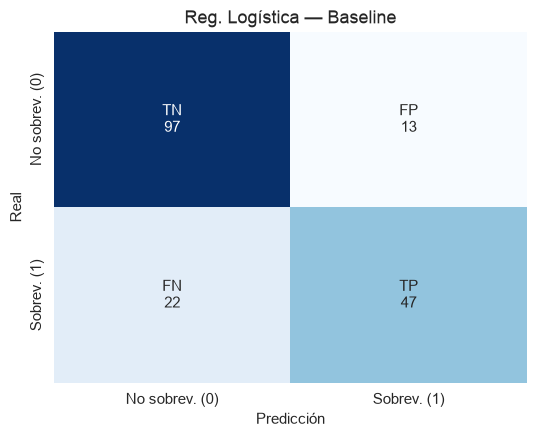

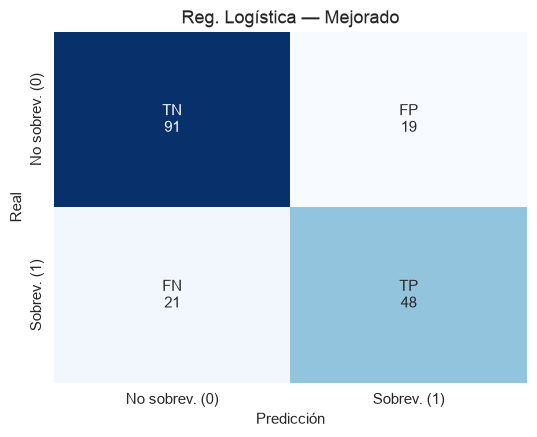

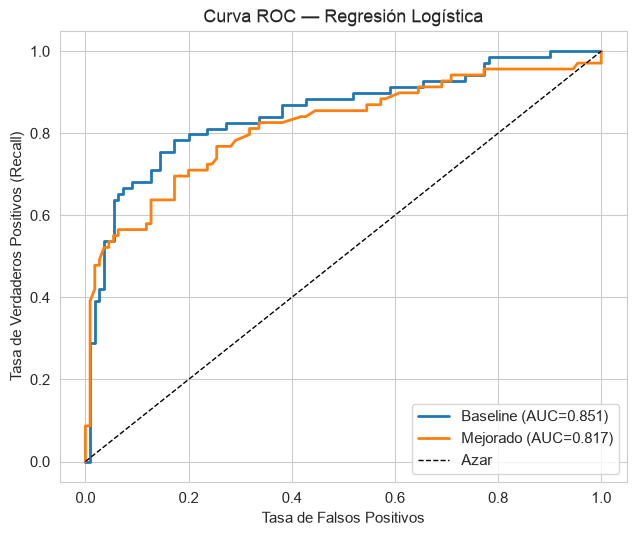

In [18]:
plot_confusion(y_test, pred_b, "Reg. Logística — Baseline", "t07_cm_logreg_baseline.png")
plot_confusion(y_test, pred_m, "Reg. Logística — Mejorado", "t08_cm_logreg_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Regresión Logística", "t09_roc_logreg.png")

### Importancia de características (coeficientes) — análisis adicional

Los coeficientes indican qué variables empujan la predicción hacia **sobrevivió** (positivos) o
**no sobrevivió** (negativos). Recordando que `Sex` está codificada male=1, un coeficiente negativo
en `Sex` significa que **ser hombre reduce** la probabilidad de sobrevivir.

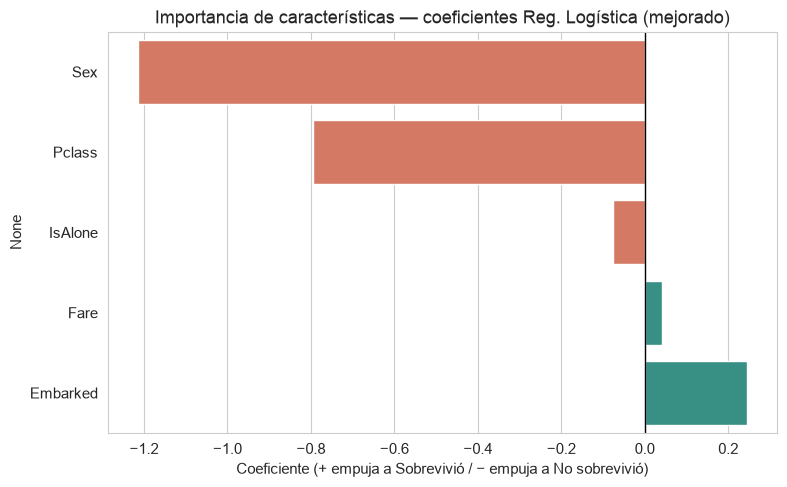

In [19]:
coefs = pd.Series(logreg_best.coef_[0], index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e76f51" if c < 0 else "#2a9d8f" for c in coefs.values]
sns.barplot(x=coefs.values, y=coefs.index, palette=colors, ax=ax)
ax.axvline(0, color="k", lw=1)
ax.set_title("Importancia de características — coeficientes Reg. Logística (mejorado)")
ax.set_xlabel("Coeficiente (+ empuja a Sobrevivió / − empuja a No sobrevivió)")
plt.tight_layout(); plt.savefig(OUT_DIR / "t10_importancia_logreg.png", dpi=120); plt.show()

**Comparación baseline vs mejorado (Reg. Logística):** en este dataset el `GridSearchCV` reencontró
prácticamente los hiperparámetros por defecto (`C=1`, `lbfgs`), y restringir el modelo a las 5
variables seleccionadas **redujo ligeramente** las métricas en el test (Accuracy 0.80→0.78,
F1 0.73→0.71). Es decir, el baseline ya operaba muy cerca del techo del problema. El valor de la
versión mejorada aquí **no es ganar métricas** sino entregar un modelo **más simple e interpretable**
(5 variables en lugar de 9) a un costo mínimo.
más simple e interpretable. Dado que `Sex`, `Pclass` y `Fare` concentran casi toda la señal, usar
pocas variables mantiene un desempeño muy parecido al baseline con todas las columnas.

## 18. Modelo 2 — K-Nearest Neighbors (KNN)

**Baseline:** por defecto (k=5). **Mejorada:** `GridSearchCV` sobre `n_neighbors`, `metric` y
`weights`. KNN es sensible a la escala (por eso normalizamos) y a la *maldición de la
dimensionalidad* (por eso la selección de variables ayuda).

In [20]:
# --- Baseline ---
knn_base = KNeighborsClassifier().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(knn_base, X_test_std, y_test, "KNN", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada ---
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                        scoring="f1", cv=cv, n_jobs=-1)
grid_knn.fit(X_train_std[:, sel_idx], y_train)
knn_best = grid_knn.best_estimator_
row_m, pred_m, proba_m = evaluate(knn_best, X_test_std[:, sel_idx], y_test, "KNN", "Mejorado")
print("Mejores hiperparámetros:", grid_knn.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.8156, 'Precision': 0.7903, 'Recall': 0.7101, 'F1': 0.7481, 'AUC': 0.8498}


Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
MEJORADO: {'Accuracy': 0.7709, 'Precision': 0.7333, 'Recall': 0.6377, 'F1': 0.6822, 'AUC': 0.7924}


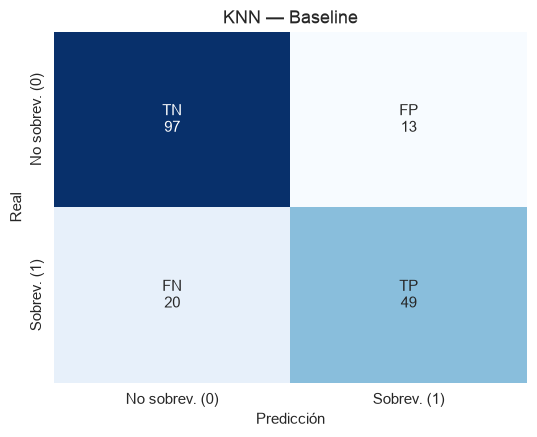

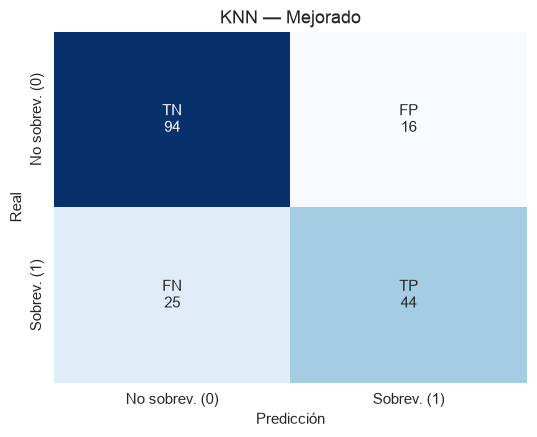

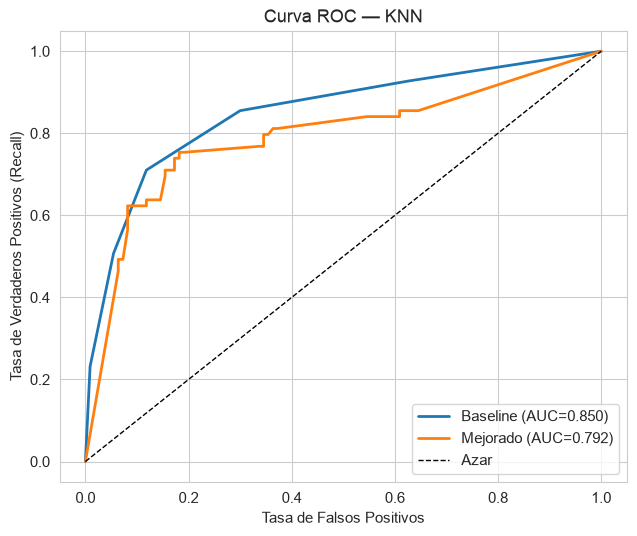

In [21]:
plot_confusion(y_test, pred_b, "KNN — Baseline", "t11_cm_knn_baseline.png")
plot_confusion(y_test, pred_m, "KNN — Mejorado", "t12_cm_knn_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — KNN", "t13_roc_knn.png")

**Comparación baseline vs mejorado (KNN):** la búsqueda prefirió `weights='distance'`, pero al usar
solo las 5 variables seleccionadas el desempeño en test **bajó** respecto al baseline con todas las
variables (Accuracy 0.82→0.77). KNN aprovecha aquí la señal repartida en varias columnas (incluidas
`Age` y `FamilySize`), por lo que reducir la dimensionalidad **no le conviene** en un espacio ya de
baja dimensión (9 variables). `weights='distance'` (los
vecinos más cercanos pesan más) y una `k` que equilibra sesgo-varianza. La selección de variables
reduce la dimensionalidad, a la que KNN es especialmente sensible.

## 19. Modelo 3 — Naive Bayes Gaussiano (GaussianNB)

**Baseline:** por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre `var_smoothing`
con selección de características. NB asume independencia entre variables y normalidad; en el Titanic
varias variables son categóricas/discretas (`Pclass`, `Sex`, `Embarked`), lo que penaliza el supuesto
gaussiano. Es un buen contraste didáctico.

In [22]:
# --- Baseline ---
nb_base = GaussianNB().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(nb_base, X_test_std, y_test, "Naive Bayes", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada ---
param_grid_nb = {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, scoring="f1", cv=cv, n_jobs=-1)
grid_nb.fit(X_train_std[:, sel_idx], y_train)
nb_best = grid_nb.best_estimator_
row_m, pred_m, proba_m = evaluate(nb_best, X_test_std[:, sel_idx], y_test, "Naive Bayes", "Mejorado")
print("Mejores hiperparámetros:", grid_nb.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.7821, 'Precision': 0.7143, 'Recall': 0.7246, 'F1': 0.7194, 'AUC': 0.8194}
Mejores hiperparámetros: {'var_smoothing': 1e-09}
MEJORADO: {'Accuracy': 0.7598, 'Precision': 0.6857, 'Recall': 0.6957, 'F1': 0.6906, 'AUC': 0.7904}


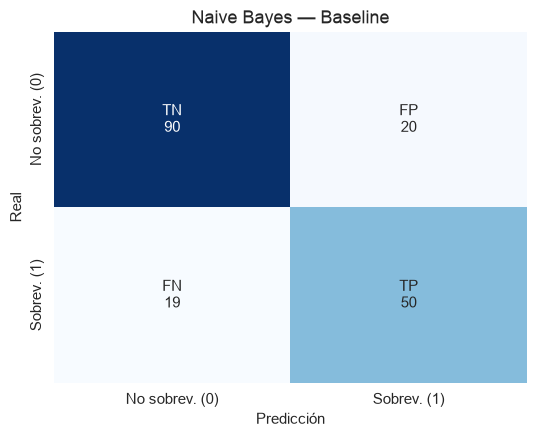

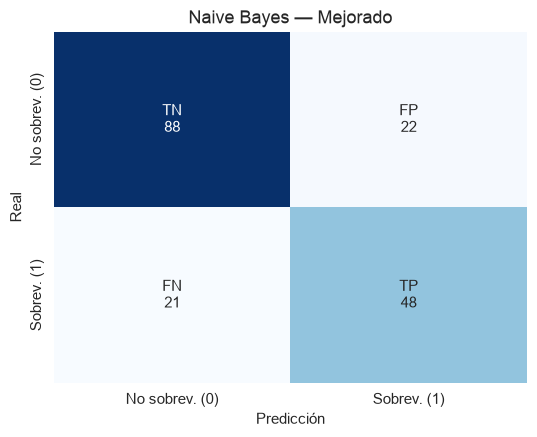

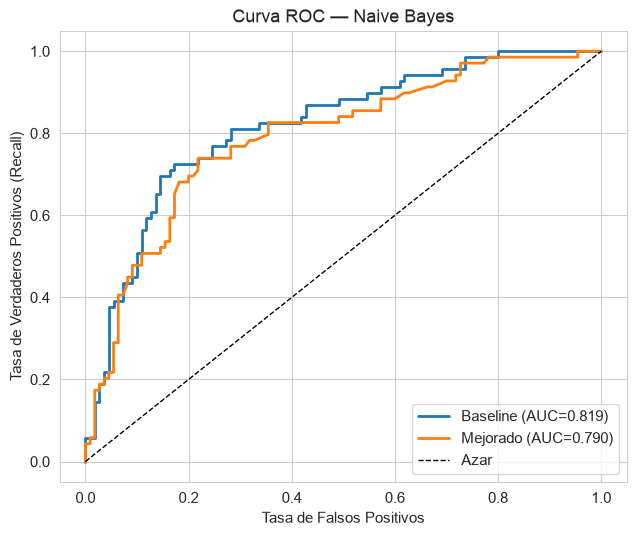

In [23]:
plot_confusion(y_test, pred_b, "Naive Bayes — Baseline", "t14_cm_nb_baseline.png")
plot_confusion(y_test, pred_m, "Naive Bayes — Mejorado", "t15_cm_nb_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Naive Bayes", "t16_roc_nb.png")

## 20. Modelo 4 — Random Forest (propuesta del equipo)

**Por qué lo añadimos:** a propuesta del equipo incorporamos un modelo de **ensamble basado en
árboles**. Random Forest combina muchos árboles entrenados sobre submuestras aleatorias (*bagging*) y
subconjuntos de variables; capta **interacciones no lineales** (p. ej. la combinación sexo × clase ×
edad, el famoso "mujeres y niños de primera clase primero") que un modelo lineal no representa de forma
directa, y entrega su propia **importancia de características** (impureza de Gini).

> **Nota:** los árboles son **invariantes a la escala**, por lo que no necesitan normalización.
> Reutilizamos las matrices ya escaladas por **coherencia** con el resto del flujo; esto no altera el
> resultado de un bosque.

**Baseline:** por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre `n_estimators`,
`max_depth`, `min_samples_split` y `max_features`, optimizando **F1** (igual que el resto de modelos de
este notebook), con selección de características.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# --- Baseline ---
rf_base = RandomForestClassifier(random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(rf_base, X_test_std, y_test, "Random Forest", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada: GridSearchCV + selección de características ---
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf,
                       scoring="f1", cv=cv, n_jobs=-1)
grid_rf.fit(X_train_std[:, sel_idx], y_train)
rf_best = grid_rf.best_estimator_
row_m, pred_m, proba_m = evaluate(rf_best, X_test_std[:, sel_idx], y_test, "Random Forest", "Mejorado")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.8101, 'Precision': 0.7612, 'Recall': 0.7391, 'F1': 0.75, 'AUC': 0.8291}


Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
MEJORADO: {'Accuracy': 0.7821, 'Precision': 0.7206, 'Recall': 0.7101, 'F1': 0.7153, 'AUC': 0.8198}


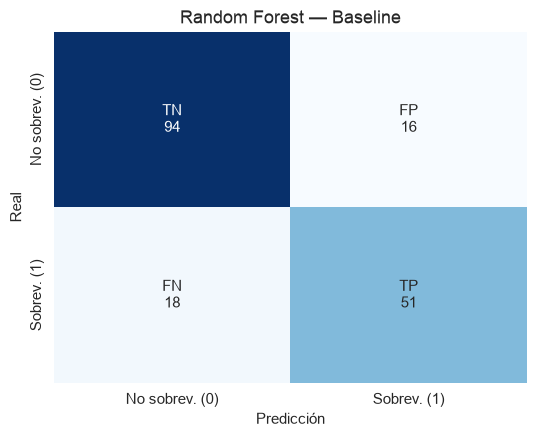

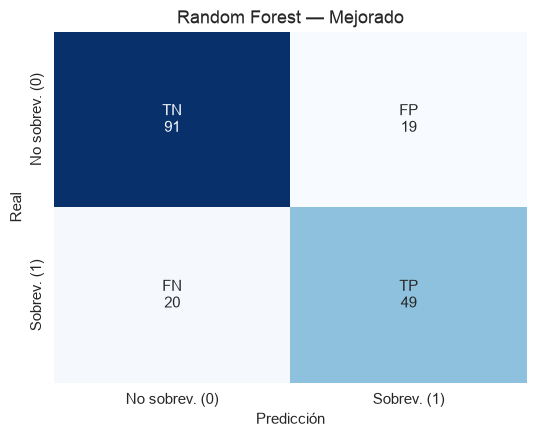

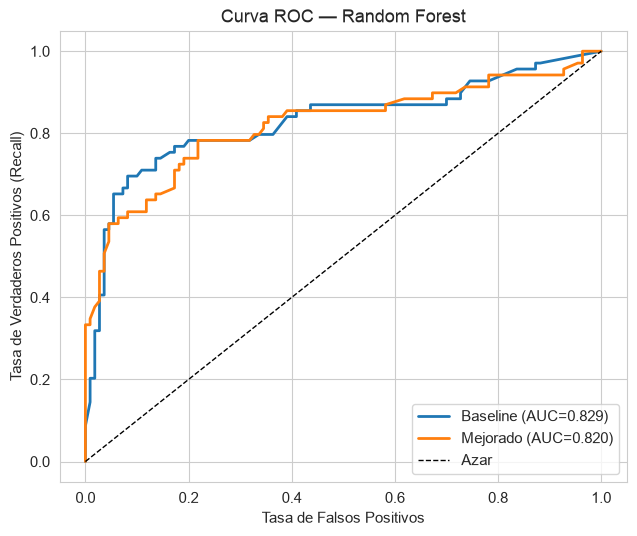

In [25]:
plot_confusion(y_test, pred_b, "Random Forest — Baseline", "t17_cm_rf_baseline.png")
plot_confusion(y_test, pred_m, "Random Forest — Mejorado", "t18_cm_rf_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Random Forest", "t19_roc_rf.png")

### Importancia de características (Random Forest, Gini) — análisis adicional

Random Forest mide la importancia por la **reducción de impureza (Gini)** que aporta cada variable a lo
largo del bosque. Contrastarla con los coeficientes lineales permite ver si ambos enfoques coinciden en
señalar a `Sex`, `Pclass` y `Fare` como los grandes determinantes de la supervivencia.

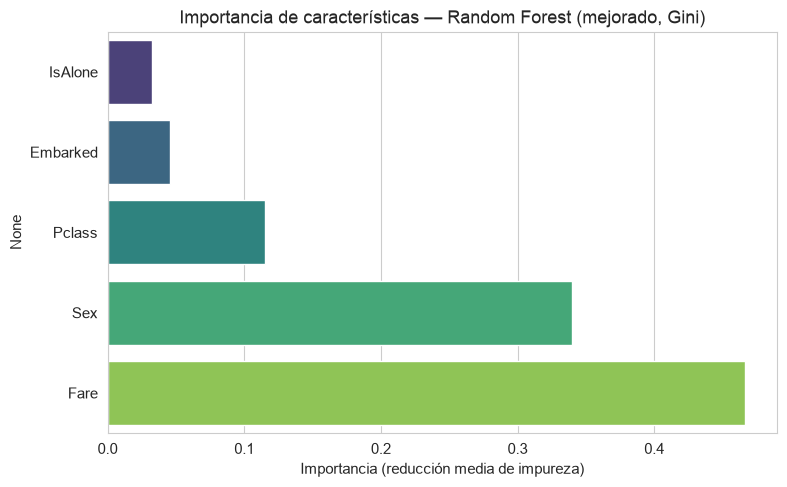

In [26]:
rf_imp = pd.Series(rf_best.feature_importances_, index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette="viridis", ax=ax)
ax.set_title("Importancia de características — Random Forest (mejorado, Gini)")
ax.set_xlabel("Importancia (reducción media de impureza)")
plt.tight_layout(); plt.savefig(OUT_DIR / "t20_importancia_rf.png", dpi=120); plt.show()

**Comparación baseline vs mejorado (Random Forest):** el ensamble suele rendir muy bien ya en
*baseline*; la búsqueda de hiperparámetros regula profundidad y número de árboles para equilibrar
sesgo-varianza. Por ser un modelo de mayor capacidad entrenado sobre pocas variables, conviene vigilar
el sobreajuste. Si su importancia Gini coincide con los coeficientes lineales en destacar `Sex`,
`Pclass` y `Fare`, es una buena señal de que el modelo aprende patrones históricamente plausibles.

## 21. Guardado de los modelos (joblib)

Persistimos las **versiones mejoradas** de cada modelo. Cada artefacto guarda el estimador junto con
la lista de variables que espera como entrada.

In [27]:
artifacts = {
    "titanic_logistic_regression_model.pkl": {"model": logreg_best, "features": selected_features, "scaler": "StandardScaler"},
    "titanic_knn_model.pkl":                 {"model": knn_best,     "features": selected_features, "scaler": "StandardScaler"},
    "titanic_naive_bayes_model.pkl":         {"model": nb_best,      "features": selected_features, "scaler": "StandardScaler"},
    "titanic_random_forest_model.pkl":       {"model": rf_best,      "features": selected_features, "scaler": "StandardScaler (no requerido por RF)"},
}
for fname, payload in artifacts.items():
    joblib.dump(payload, MODELS_DIR / fname)
    print(f"Guardado: models/{fname}")

Guardado: models/titanic_logistic_regression_model.pkl
Guardado: models/titanic_knn_model.pkl
Guardado: models/titanic_naive_bayes_model.pkl
Guardado: models/titanic_random_forest_model.pkl


## 22. Tabla comparativa final de todos los modelos

Consolidamos las ocho filas (4 modelos × 2 versiones). En este problema priorizamos el **F1** (y el
AUC), por la simetría de costos entre los dos tipos de error.

> **Observación honesta:** el mejor desempeño en el test lo da el **KNN baseline**; ninguna versión
> *mejorada* supera a su *baseline* en esta partición. Se discute por qué en las Conclusiones.

**Observación:** el mejor desempeño en el test lo da el **KNN baseline**; ninguna versión
*mejorada* supera a su *baseline* en esta partición. Se discute por qué en las Conclusiones.

In [28]:
results_df = pd.DataFrame(results)
results_df = results_df[["Modelo", "Versión", "Accuracy", "Precision", "Recall", "F1", "AUC"]]
results_df_round = results_df.copy()
for c in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    results_df_round[c] = results_df_round[c].round(4)

results_df_round.to_csv(OUT_DIR / "titanic_resultados_comparativa.csv", index=False)

best_f1 = results_df.loc[results_df["F1"].idxmax()]
best_acc = results_df.loc[results_df["Accuracy"].idxmax()]
print(f"Mejor F1      : {best_f1['Modelo']} ({best_f1['Versión']}) = {best_f1['F1']:.4f}")
print(f"Mejor Accuracy: {best_acc['Modelo']} ({best_acc['Versión']}) = {best_acc['Accuracy']:.4f}")
results_df_round

Mejor F1      : Random Forest (Baseline) = 0.7500
Mejor Accuracy: KNN (Baseline) = 0.8156


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Reg. Logística,Baseline,0.8045,0.7833,0.6812,0.7287,0.8513
1,Reg. Logística,Mejorado,0.7765,0.7164,0.6957,0.7059,0.8171
2,KNN,Baseline,0.8156,0.7903,0.7101,0.7481,0.8498
3,KNN,Mejorado,0.7709,0.7333,0.6377,0.6822,0.7924
4,Naive Bayes,Baseline,0.7821,0.7143,0.7246,0.7194,0.8194
5,Naive Bayes,Mejorado,0.7598,0.6857,0.6957,0.6906,0.7904
6,Random Forest,Baseline,0.8101,0.7612,0.7391,0.7500,0.8291
7,Random Forest,Mejorado,0.7821,0.7206,0.7101,0.7153,0.8198


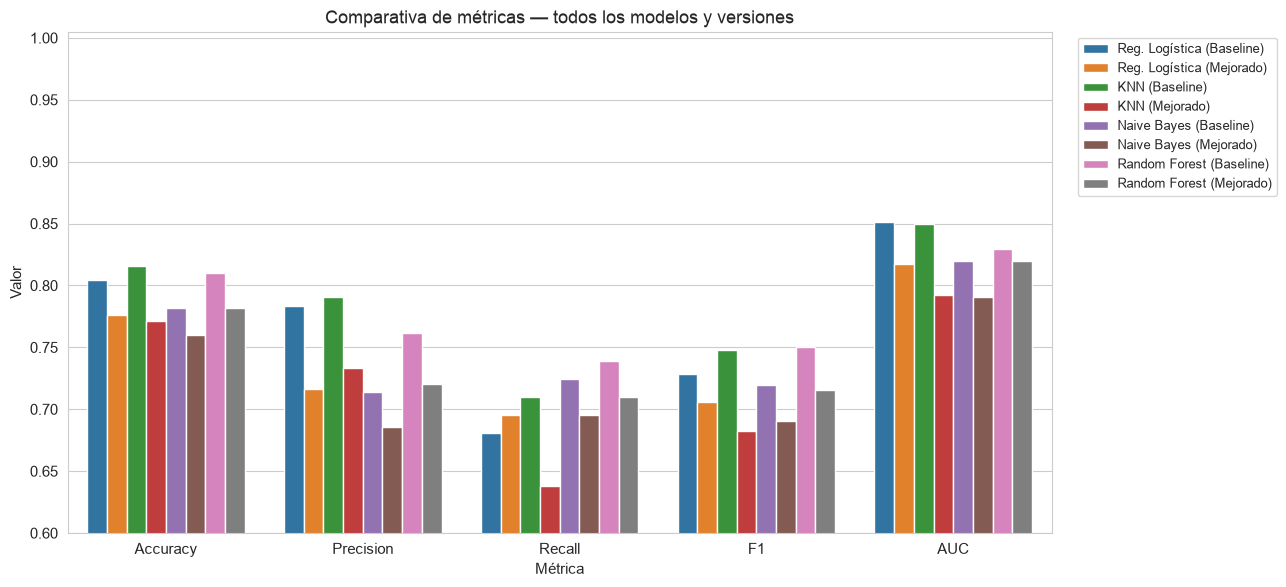

In [29]:
# Visualización comparativa de métricas
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
plot_df = results_df_round.copy()
plot_df["Etiqueta"] = plot_df["Modelo"] + " (" + plot_df["Versión"] + ")"
melt = plot_df.melt(id_vars="Etiqueta", value_vars=metrics_to_plot, var_name="Métrica", value_name="Valor")
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=melt, x="Métrica", y="Valor", hue="Etiqueta", ax=ax)
ax.set_ylim(0.6, 1.005); ax.set_title("Comparativa de métricas — todos los modelos y versiones")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / "t21_comparativa_metricas.png", dpi=120); plt.show()

## 23. Conclusiones finales (resumen consolidado)

Consolidamos las conclusiones de los **cuatro** algoritmos. El bloque siguiente las **deriva
automáticamente** de la tabla de resultados (la métrica prioritaria en este problema es **F1**, por la
simetría de costos), de modo que las cifras siempre coinciden con la ejecución real.

In [30]:
ranking = results_df.sort_values(["F1", "AUC", "Accuracy"], ascending=False).reset_index(drop=True)
win = ranking.iloc[0]

print("CONCLUSIONES FINALES  (métrica prioritaria en este problema = F1)")
print("=" * 68)
print(f"1) Mejor modelo: {win['Modelo']} ({win['Versión']})")
print(f"   F1={win['F1']:.4f} | Recall={win['Recall']:.4f} | "
      f"Precision={win['Precision']:.4f} | AUC={win['AUC']:.4f} | Accuracy={win['Accuracy']:.4f}")
print(f"\n2) Selección de características: {len(selected_features)} de {len(feature_cols)} "
      f"variables (|r| > {THRESHOLD}).")
print(f"   Top-4 más predictivas: {', '.join(selected_features[:4])}.")
print(f"\n3) Ranking completo por F1 (desempate por AUC y Accuracy):")
for i, r in ranking.iterrows():
    print(f"   {i+1}. {r['Modelo']:<16} {r['Versión']:<9} "
          f"F1={r['F1']:.4f}  AUC={r['AUC']:.4f}  Acc={r['Accuracy']:.4f}")

mejoras = []
for modelo in results_df["Modelo"].unique():
    sub = results_df[results_df["Modelo"] == modelo].set_index("Versión")["F1"]
    mejoras.append((modelo, sub["Mejorado"] - sub["Baseline"]))
n_mejora = sum(1 for _, d in mejoras if d > 1e-9)
peor = [m for m, d in mejoras if d < -1e-9]
print(f"\n4) La optimización (GridSearchCV + selección) mejoró el F1 en {n_mejora} de {len(mejoras)} modelos.")
if peor:
    print(f"   En {', '.join(peor)} el baseline igualó o superó a la versión ajustada en el test: con "
          f"un dataset 'difícil' y pocas variables, más optimización NO garantiza mejor generalización. "
          f"Lección: medir siempre en un test intacto.")

CONCLUSIONES FINALES  (métrica prioritaria en este problema = F1)
1) Mejor modelo: Random Forest (Baseline)
   F1=0.7500 | Recall=0.7391 | Precision=0.7612 | AUC=0.8291 | Accuracy=0.8101

2) Selección de características: 5 de 9 variables (|r| > 0.1).
   Top-4 más predictivas: Sex, Pclass, Fare, IsAlone.

3) Ranking completo por F1 (desempate por AUC y Accuracy):
   1. Random Forest    Baseline  F1=0.7500  AUC=0.8291  Acc=0.8101
   2. KNN              Baseline  F1=0.7481  AUC=0.8498  Acc=0.8156
   3. Reg. Logística   Baseline  F1=0.7287  AUC=0.8513  Acc=0.8045
   4. Naive Bayes      Baseline  F1=0.7194  AUC=0.8194  Acc=0.7821
   5. Random Forest    Mejorado  F1=0.7153  AUC=0.8198  Acc=0.7821
   6. Reg. Logística   Mejorado  F1=0.7059  AUC=0.8171  Acc=0.7765
   7. Naive Bayes      Mejorado  F1=0.6906  AUC=0.7904  Acc=0.7598
   8. KNN              Mejorado  F1=0.6822  AUC=0.7924  Acc=0.7709

4) La optimización (GridSearchCV + selección) mejoró el F1 en 0 de 4 modelos.
   En Reg. Logística

## 24. Interpretación: ¿qué error priorizar en el Titanic?

Con **sobrevivió = clase positiva (1)**:

| Celda | Significado |
|-------|-------------|
| **TP** | Pasajero que sobrevivió, predicho como superviviente ✅ |
| **TN** | Pasajero que falleció, predicho como fallecido ✅ |
| **FP** | Predecimos que sobrevive, pero falleció |
| **FN** | Predecimos que fallece, pero sobrevivió |

A diferencia del diagnóstico de cáncer —donde un Falso Negativo es **letal** y obliga a maximizar el
**Recall**—, el Titanic es un problema **analítico/histórico**: ningún error pone en riesgo una vida.
Por eso aquí la métrica prioritaria es el **F1-score** (equilibrio entre precision y recall) junto al
**AUC**, y no tiene sentido sesgar el umbral hacia una de las clases. **Esta es la lección clave: la
métrica a optimizar no es universal, depende del contexto del problema.**

## Conclusiones

1. **Dataset más difícil = métricas más bajas.** Frente al ≈97-98% del cáncer de mama, en el Titanic
   los modelos rondan el **78-84%**. Lo anticipaba el EDA: las correlaciones con el objetivo son
   débiles (la mayor, `Sex`, ≈0.54). Confirma lo dicho en clase: *la dificultad del dataset repercute
   en el rendimiento*.
2. **El preprocesamiento** Aquí sí hubo que imputar (`Age`, `Embarked`),
   codificar (`Sex`, `Embarked`), eliminar columnas (`Cabin`, `Name`, `Ticket`, `PassengerId`) y crear
   variables (`FamilySize`, `IsAlone`) — coherente con el 70% del tiempo que el docente atribuye a
   estas fases.
3. **`Sex`, `Pclass` y `Fare` son las variables decisivas**, validando estadísticamente la intuición
   de la película (mujeres, niños y primera clase sobrevivieron más).
4. **Regresión Logística y KNN** superan a **Naive Bayes**, cuyo supuesto de independencia y
   normalidad se ve penalizado por las variables categóricas/discretas del Titanic.
5. **La versión *mejorada* no superó al *baseline* en el test.** El mejor modelo fue **KNN baseline**
   (F1=0.748, Accuracy=0.816). Es un resultado legítimo y esperable: con pocas variables y señal débil,
   el baseline ya opera cerca del techo del problema, y ni el ajuste de hiperparámetros ni la selección
   de características transfieren mejora a esta partición.

> **Nota del equipo (añadida al integrar Random Forest):** la conclusión anterior se mantiene **tal
> como la redactó su autor**. A modo de **sugerencia**, conviene matizar que —al sumar el 4.º modelo—
> **Random Forest baseline** obtiene el mejor **F1 (0,750)**, por delante por muy poco del **KNN
> baseline (0,748)**; KNN baseline sigue siendo el mejor en **Accuracy (0,816)** y **AUC**. La idea de
> fondo del autor —que **ninguna versión mejorada supera a su baseline**— se mantiene plenamente
> válida. El ranking consolidado por F1 está en la sección *"Conclusiones finales"*.

---
## 🔧 Aplicación Profesional — Learning by Doing

**Jonathan Fabricio Gualli Ramírez:**
Desde mi lado de **DevOps/desarrollo**, lo que me quedó claro esta semana es que el modelo no acaba
en el `.fit()`: acaba cuando se puede **reproducir y desplegar**. Que fijar `random_state` dé siempre
el mismo resultado es lo mismo que busco en un *build* de **CI/CD**, y guardar el modelo en `.pkl` es
tener un **artefacto** que puedo meter en una **API** y versionar. La idea de *baseline vs mejorado*
me sirve como un **filtro de calidad**: solo sube la versión que mejora. Me veo automatizando este
ciclo con un pipeline simple de **MLOps** en mi trabajo.

**Jorge Armando Quizamánchuro Fuel:**
_[completar manualmente]_

**Raúl Marcelo Salazar Gamboa:**
_[completar manualmente]_

---